
Running Re = 2000
nu = 5.000000e-04
dt = 1.000000e-03
Iter     1   Residual = 1.750e-04
Iter   200   Residual = 4.125e-05
Iter   400   Residual = 2.836e-05
Iter   600   Residual = 2.203e-05
Iter   800   Residual = 1.833e-05
Iter  1000   Residual = 1.589e-05
Iter  1200   Residual = 1.534e-05
Iter  1400   Residual = 1.499e-05
Iter  1600   Residual = 1.457e-05
Iter  1800   Residual = 1.410e-05
Iter  2000   Residual = 1.362e-05
Iter  2200   Residual = 1.308e-05
Iter  2400   Residual = 1.250e-05
Iter  2600   Residual = 1.186e-05
Iter  2800   Residual = 1.118e-05
Iter  3000   Residual = 1.045e-05
Iter  3200   Residual = 9.705e-06
Iter  3400   Residual = 8.964e-06
Iter  3600   Residual = 8.254e-06
Iter  3800   Residual = 7.587e-06
Iter  4000   Residual = 6.973e-06
Iter  4200   Residual = 6.414e-06
Iter  4400   Residual = 5.908e-06
Iter  4600   Residual = 5.452e-06
Iter  4800   Residual = 5.043e-06
Iter  5000   Residual = 4.675e-06

Running Re = 4000
nu = 2.500000e-04
dt = 1.000000e-03
Iter  

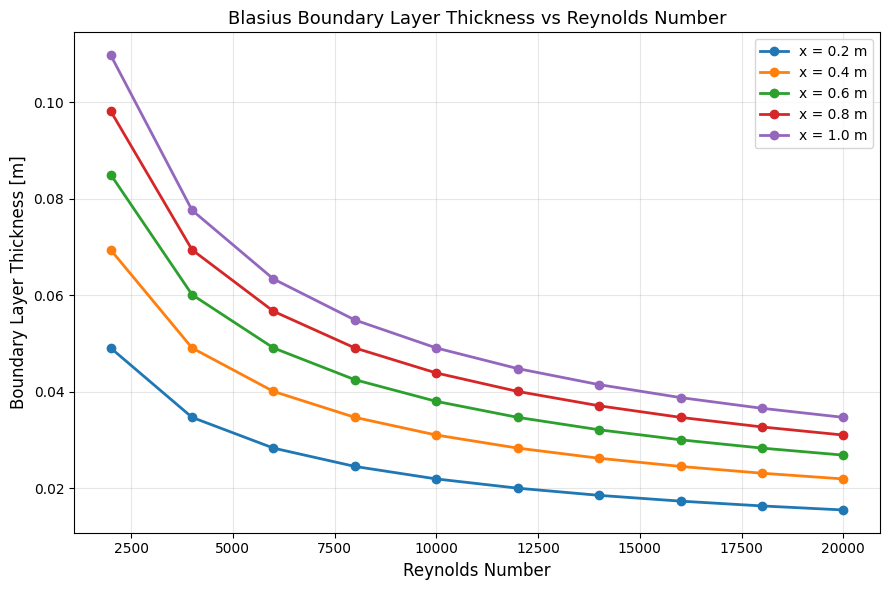

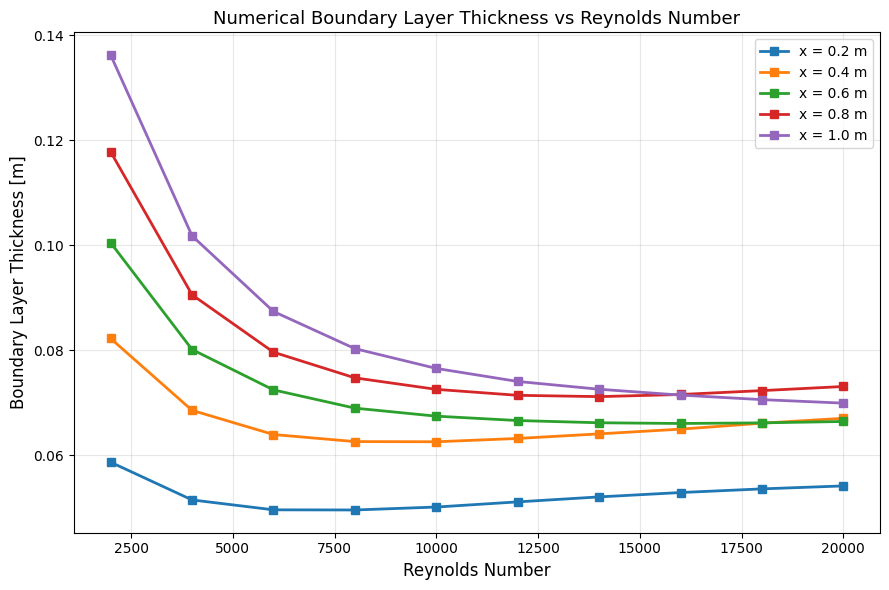

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# FLAT PLATE BOUNDARY LAYER
# STREAM FUNCTION - VORTICITY FORMULATION
# ==========================================================

# ==========================================================
# DOMAIN
# ==========================================================
Lx = 1.0
Ly = 1.0

nx = 201
ny = 201

dx = Lx / (nx - 1)
dy = Ly / (ny - 1)

# Grid
x = np.linspace(0.0, Lx, nx)
y = np.linspace(0.0, Ly, ny)

X, Y = np.meshgrid(x, y)

# ==========================================================
# FLOW PARAMETERS
# ==========================================================
U_inf = 1.0

# Reynolds numbers
Re_values = np.arange(2000, 20001, 2000)

# Fixed x-locations
x_locations = [0.2, 0.4, 0.6, 0.8, 1.0]

# ==========================================================
# STORAGE
# ==========================================================
blasius_results = {
    xloc: [] for xloc in x_locations
}

numerical_results = {
    xloc: [] for xloc in x_locations
}

# ==========================================================
# LOOP OVER REYNOLDS NUMBERS
# ==========================================================
for Re_L in Re_values:

    print("\n" + "=" * 60)
    print(f"Running Re = {Re_L}")
    print("=" * 60)

    # ------------------------------------------------------
    # KINEMATIC VISCOSITY
    # ------------------------------------------------------
    nu = U_inf * Lx / Re_L

    # ------------------------------------------------------
    # STABLE TIME STEP
    # ------------------------------------------------------
    dt_conv = 0.2 * dx / U_inf

    dt_diff = 0.1 * dy**2 / nu

    dt = min(dt_conv, dt_diff)

    print(f"nu = {nu:.6e}")
    print(f"dt = {dt:.6e}")

    # ------------------------------------------------------
    # SOLVER PARAMETERS
    # ------------------------------------------------------
    max_iter = 5000

    poisson_iter = 80

    tol = 1e-6

    # ======================================================
    # INITIALIZE
    # ======================================================
    psi = U_inf * Y.copy()

    omega = np.zeros((ny, nx))

    # ======================================================
    # STREAM FUNCTION BC
    # ======================================================
    def apply_psi_bc(psi):

        # Bottom wall
        psi[0, :] = 0.0

        # Top boundary
        psi[-1, :] = psi[-2, :] + U_inf * dy

        # Inlet
        psi[:, 0] = U_inf * y

        # Outlet
        psi[:, -1] = 2 * psi[:, -2] - psi[:, -3]

        return psi

    # ======================================================
    # VELOCITY RECOVERY
    # ======================================================
    def recover_velocity(psi):

        u = np.zeros_like(psi)

        v = np.zeros_like(psi)

        # Interior nodes
        u[1:-1, 1:-1] = (
            psi[2:, 1:-1]
            - psi[:-2, 1:-1]
        ) / (2 * dy)

        v[1:-1, 1:-1] = -(
            psi[1:-1, 2:]
            - psi[1:-1, :-2]
        ) / (2 * dx)

        # Bottom wall
        u[0, :] = 0.0
        v[0, :] = 0.0

        # Top boundary
        u[-1, :] = U_inf
        v[-1, :] = 0.0

        # Inlet
        u[:, 0] = U_inf
        v[:, 0] = 0.0

        # Outlet
        u[:, -1] = u[:, -2]
        v[:, -1] = v[:, -2]

        return u, v

    # ======================================================
    # VORTICITY BC
    # ======================================================
    def apply_omega_bc(omega, psi):

        # Bottom wall
        omega[0, 1:-1] = (
            -2.0 * psi[1, 1:-1]
            / dy**2
        )

        # Top
        omega[-1, :] = 0.0

        # Inlet
        omega[:, 0] = 0.0

        # Outlet
        omega[:, -1] = (
            2 * omega[:, -2]
            - omega[:, -3]
        )

        return omega

    # ======================================================
    # POISSON SOLVER
    # ======================================================
    def solve_poisson(psi, omega):

        dx2 = dx**2

        dy2 = dy**2

        coeff = 2 / dx2 + 2 / dy2

        for _ in range(poisson_iter):

            psi[1:-1, 1:-1] = (

                (psi[1:-1, 2:]
                 + psi[1:-1, :-2]) / dx2

                + (psi[2:, 1:-1]
                   + psi[:-2, 1:-1]) / dy2

                + omega[1:-1, 1:-1]

            ) / coeff

            psi = apply_psi_bc(psi)

        return psi

    # ======================================================
    # INITIAL BC
    # ======================================================
    psi = apply_psi_bc(psi)

    omega = apply_omega_bc(omega, psi)

    # ======================================================
    # MAIN ITERATION LOOP
    # ======================================================
    for it in range(1, max_iter + 1):

        psi_old = psi.copy()

        # --------------------------------------------------
        # VELOCITY
        # --------------------------------------------------
        u, v = recover_velocity(psi)

        omega = apply_omega_bc(omega, psi)

        omega_c = omega[1:-1, 1:-1]

        u_c = u[1:-1, 1:-1]

        v_c = v[1:-1, 1:-1]

        # --------------------------------------------------
        # UPWIND CONVECTION
        # --------------------------------------------------
        domega_dx = np.where(
            u_c >= 0.0,

            (omega[1:-1, 1:-1]
             - omega[1:-1, :-2]) / dx,

            (omega[1:-1, 2:]
             - omega[1:-1, 1:-1]) / dx
        )

        domega_dy = np.where(
            v_c >= 0.0,

            (omega[1:-1, 1:-1]
             - omega[:-2, 1:-1]) / dy,

            (omega[2:, 1:-1]
             - omega[1:-1, 1:-1]) / dy
        )

        # --------------------------------------------------
        # DIFFUSION
        # --------------------------------------------------
        d2omega_dx2 = (
            omega[1:-1, 2:]
            - 2 * omega_c
            + omega[1:-1, :-2]
        ) / dx**2

        d2omega_dy2 = (
            omega[2:, 1:-1]
            - 2 * omega_c
            + omega[:-2, 1:-1]
        ) / dy**2

        # --------------------------------------------------
        # UPDATE
        # --------------------------------------------------
        omega_new = omega.copy()

        omega_new[1:-1, 1:-1] = (

            omega_c

            + dt * (

                -u_c * domega_dx

                -v_c * domega_dy

                + nu * (
                    d2omega_dx2
                    + d2omega_dy2
                )
            )
        )

        # Stability clipping
        omega_new = np.clip(
            omega_new,
            -1e6,
            1e6
        )

        omega = omega_new

        omega = apply_omega_bc(omega, psi)

        # --------------------------------------------------
        # SOLVE POISSON
        # --------------------------------------------------
        psi = solve_poisson(psi, omega)

        # --------------------------------------------------
        # RESIDUAL
        # --------------------------------------------------
        residual = np.max(
            np.abs(psi - psi_old)
        )

        if it % 200 == 0 or it == 1:

            print(
                f"Iter {it:5d}   "
                f"Residual = {residual:.3e}"
            )

        if residual < tol and it > 300:

            print(f"Converged in {it}")

            break

    # ======================================================
    # FINAL VELOCITY
    # ======================================================
    u, v = recover_velocity(psi)

    # ======================================================
    # BOUNDARY LAYER THICKNESS
    # delta_99 where u/U_inf = 0.99
    # ======================================================
    delta_99 = np.full(nx, np.nan)

    for i in range(1, nx):

        u_profile = u[:, i] / U_inf

        for j in range(1, ny):

            if (
                u_profile[j - 1] < 0.99
                and
                u_profile[j] >= 0.99
            ):

                y1 = y[j - 1]
                y2 = y[j]

                u1 = u_profile[j - 1]
                u2 = u_profile[j]

                delta_99[i] = y1 + (

                    (0.99 - u1)

                    * (y2 - y1)

                    / (u2 - u1)
                )

                break

    # ======================================================
    # BLASIUS SOLUTION
    # SKIP x = 0 TO AVOID DIVISION BY ZERO
    # ======================================================
    x_bl = x[1:]

    Re_x = U_inf * x_bl / nu

    delta_blasius = (
        4.91 * x_bl
        / np.sqrt(Re_x)
    )

    # ======================================================
    # STORE RESULTS
    # ======================================================
    for xloc in x_locations:

        idx_num = np.argmin(
            np.abs(x - xloc)
        )

        idx_bl = np.argmin(
            np.abs(x_bl - xloc)
        )

        numerical_results[xloc].append(
            delta_99[idx_num]
        )

        blasius_results[xloc].append(
            delta_blasius[idx_bl]
        )

# ==========================================================
# PLOT 1 : BLASIUS SOLUTION
# ==========================================================
plt.figure(figsize=(9, 6))

for xloc in x_locations:

    plt.plot(
        Re_values,
        blasius_results[xloc],
        marker='o',
        linewidth=2,
        label=f"x = {xloc} m"
    )

plt.xlabel(
    "Reynolds Number",
    fontsize=12
)

plt.ylabel(
    "Boundary Layer Thickness [m]",
    fontsize=12
)

plt.title(
    "Blasius Boundary Layer Thickness vs Reynolds Number",
    fontsize=13
)

plt.grid(True, alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()

# ==========================================================
# PLOT 2 : NUMERICAL SOLUTION
# ==========================================================
plt.figure(figsize=(9, 6))

for xloc in x_locations:

    plt.plot(
        Re_values,
        numerical_results[xloc],
        marker='s',
        linewidth=2,
        label=f"x = {xloc} m"
    )

plt.xlabel(
    "Reynolds Number",
    fontsize=12
)

plt.ylabel(
    "Boundary Layer Thickness [m]",
    fontsize=12
)

plt.title(
    "Numerical Boundary Layer Thickness vs Reynolds Number",
    fontsize=13
)

plt.grid(True, alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()